# Uebung 3 - Unwuchterregung

Kurze Beschreibung der Aufgabe

In Uebung 3 betrachten wir die statische Unwuchterregung. Dabei wird das System aufgrund einer inhomogenen Masseverteilung zu Schwingungen angeregt. 

Beispiel: Waschmaschine --> Die Kleidung wird durch Zentrifugalkräfte an den Rand der Trommel gedraengt. Infolgedessen verschiebt sich der kombinierte Schwerpunkt des Systems Trommel - Kleidung auch dahin. Nun da der Schwerpunkt nicht auf der Drehachse liegt, wird das System zu unwuchterregten Schwingungen angeregt.

Im Prinzip haben wir fuer diese Aufgabe genau die gleichen Plots wie von Aufgabe 1, Uebung 2. Hinzu kommen aber zwei weitere Frequenzplots fuer die Bodenkraft. Diese sollten in einem neuen Tab geplottet.

Aufpassen: In dieser Aufgabe ist z die Auslenkung und x der Zustandsvektor, also umgekehrt zur Aufgabe 1, Uebung 2. Tut mir Leid...

## Parameter

In [ ]:
# Bibliotheken
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import signal as signal

# phys. Parameter, Default-Werte, die Grenzen fuer die Slider sind auch angegeben
m_0 = 100    # mass of the body                  --> SLIDER, (50 bis 150), die Null als Index
m_u = 10    # mass of the rotating imbalance    --> SLIDER, (1 bis 20), das u als Index
c = 5000      # spring constant                 --> SLIDER, (2000 bis 10000)
d = 10     # damping coefficient               --> SLIDER, (0.1 bis 20)
e = 1       # eccentricity                      --> SLIDER, (0.2 bis 1.5), kannst du das e zu einem griechischen epsilon machen?

# Zeiteinstellung
T = 40
dt = 0.01
t = np.linspace(0, T, int(T/dt)+1)

# Berechnungsparameter, Default-Werte immer erstmal bei 0 lassen
z0 = 0 # initial displacement       --> SLIDER, (0 bis 10)
z0_dot = 0 # initial velocity       --> SLIDER, (0 bis 5)
x0 = (z0, z0_dot); # initial conditions

m = m_0 + m_u # wird fuer Uebersichtichkeit bei der Berechnung gebraucht
omega_0 = np.sqrt(c/m) 
delta = d/(2*m)
b2 = -m_u/m

Omega = omega_0 # angular frequency of the input --> SLIDER (bis maximal 2*omega_0 begrenzen)

In [56]:
omega_0

np.float64(6.741998624632421)

## Dauerlauf

### Auslenkungsgraph (Dauerlauf) --> 1. Tab

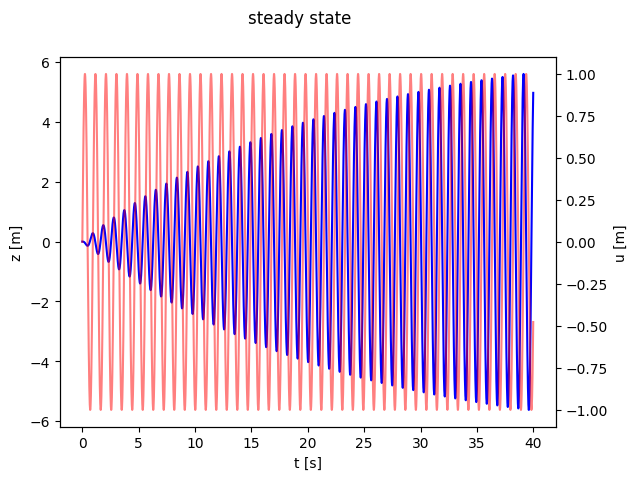

In [87]:
# Zustandsraumdarstellung fuer den Dauerlauf
def state_space_steady(x, t):
    [z, z_p] = x # Zustandsvektor --> Vom Studi auszufuellen
    x_p = [z_p, -2*delta*z_p - omega_0**2*z + b2*e*Omega**2*np.sin(Omega*t)] # Zustands-DGL --> Vom Studi auszufuellen
    return x_p

x_sol = odeint(state_space_steady, x0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist die Auslenkung x.
z = x_sol[:,0]

## Plotte die Erregung (normaler Sinus) im gleichen Figure wie Loesung
fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('z [m]')
ax1.set_xlabel('t [s]')
ax1.plot(t, z, 'b');

ax2.set_ylabel('u [m]')
ax2.plot(t, e*np.sin(Omega*t), 'r', alpha = 0.5); # default: alpha=1, so ist's durchsichtiger

plt.suptitle('steady state'); # Betitelung

# Vielleicht Grids hinzufuegen

## Hochlauf

### Auslenkungsgraph (Hochlauf) --> 1. Tab

Text(0.5, 0.98, 'acceleration')

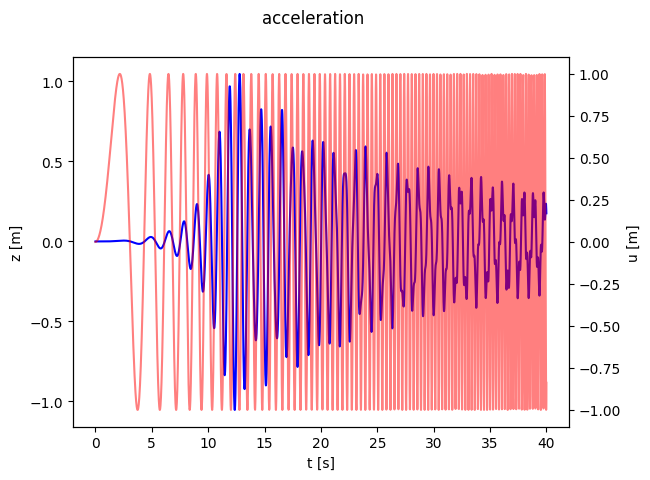

In [86]:
# Wichtig: Fuer den Hochlauf muss Omega_vec genau so groß sein wie t.
Omega_vec = np.linspace(0, 2*omega_0, t.size)

# angular acceleration of the input, Default-Wert
alpha = Omega/10 # --> SLIDER, (Omega/100 bis Omega)

# Hier wuerde ich nichts vom Studi ausfuellen lassen.
def state_space_accelerated(x, t):
    [z, z_p] = x
    x_p = [z_p, -2*delta*z_p - omega_0**2*z - b2*e*(alpha*t)**2*np.sin(0.5*alpha*t**2)]
    return x_p

x_sol = odeint(state_space_accelerated, x0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist die Auslenkung z.
z = x_sol[:,0]

fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('z [m]')
ax1.set_xlabel('t [s]')
ax1.plot(t, z, 'b');

ax2.set_ylabel('u [m]')
ax2.plot(t, e*np.sin(0.5*alpha*t**2), 'r', alpha = 0.5);

plt.suptitle('acceleration')

# Grids

### Bode-Diagramme (klassisch) --> 2. Tab

c:\Users\duong\VSCodeProjects\tm_digitalisierung\venv\Lib\site-packages\scipy\signal\_ltisys.py:2202: RuntimeWarning: divide by zero encountered in log10
  mag = 20.0 * np.log10(abs(y))
c:\Users\duong\VSCodeProjects\tm_digitalisierung\venv\Lib\site-packages\scipy\signal\_filter_design.py:187: RuntimeWarning: divide by zero encountered in divide
  h = polyval(b, s) / polyval(a, s)
c:\Users\duong\VSCodeProjects\tm_digitalisierung\venv\Lib\site-packages\scipy\signal\_filter_design.py:187: RuntimeWarning: invalid value encountered in divide
  h = polyval(b, s) / polyval(a, s)


Text(0.5, 0.98, 'Bode plots: displacement')

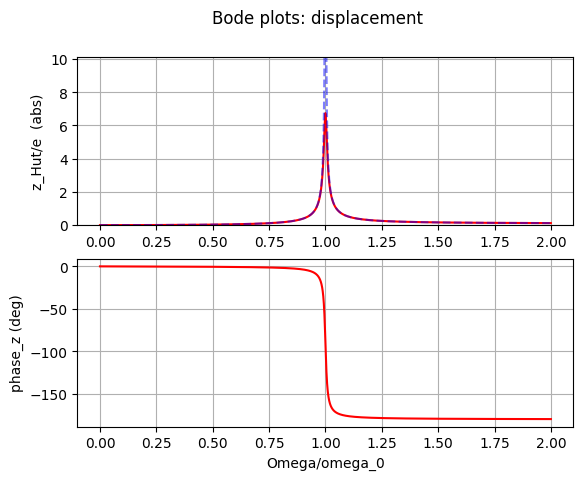

In [88]:
# transfer function
num = np.array([b2, 0, 0]);
den = np.array([1, 2*delta, omega_0**2]);
G = signal.TransferFunction(num, den);

# bode-values
_, mag, phase = signal.bode(G, Omega_vec);
mag = 10**(mag/20) # Umrechnung von dB auf abs

G_undamped = signal.TransferFunction([b2, 0, 0], [1, 0, omega_0**2]);
_, mag_undamped, phase_undamped = signal.bode(G_undamped, Omega_vec);
mag_undamped = 10**(mag_undamped/20)


plt.subplot(2,1,1)
plt.plot(Omega_vec/omega_0, mag, 'r');
plt.plot(Omega_vec/omega_0, mag_undamped, 'b--', alpha = 0.5);
plt.ylim(top = 1.5*max(mag))
plt.ylim(bottom = 0)
plt.ylabel('z_Hut/e  (abs)') #  z_Hut / epsilon --> symbolisch
plt.grid()

plt.subplot(2,1,2)
plt.plot(Omega_vec/omega_0, phase, 'r');
plt.ylabel('phase_z (deg)') # kannst du daraus phi_z mit Index z machen?
plt.xlabel('Omega/omega_0') # groß Omega / klein omega_0 --> symbolisch
plt.grid()

plt.suptitle('Bode plots: displacement')

### Bode-Diagramme (fuer Bodenkraft) --> 3. Tab

Text(0.5, 0.98, 'Bode plots: ground force')

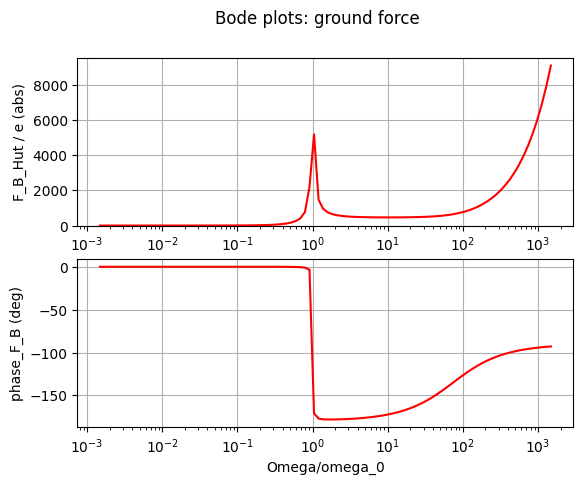

In [89]:
# transfer function
num = np.array([-2*delta*m_u, -m_u*omega_0**2, 0, 0]);
den = np.array([1, 2*delta, omega_0**2]);
G = signal.TransferFunction(num, den);

# bode-values
Omega_vec_2, mag, phase = signal.bode(G);
mag = 10**(mag/20) # Umrechnung von dB auf abs

plt.subplot(2,1,1)
plt.semilogx(Omega_vec_2/omega_0, mag, 'r');
plt.ylim(bottom = 0)
plt.ylabel('F_B_Hut / e (abs)') # --> B als Index von F, Hut ueber dem F, e zu epsilon
plt.grid()

plt.subplot(2,1,2)
plt.semilogx(Omega_vec_2/omega_0, phase, 'r');
plt.ylabel('phase_F_B (deg)') # kannst du daraus phi_F_B machen? mit F als Index von phi und B wiederum als Index von F
plt.xlabel('Omega/omega_0') # groß Omega / klein omega_0 --> symbolisch
plt.grid()

plt.suptitle('Bode plots: ground force')

# Bericht

1. Auffaelligkeiten
- Die Bode-Diagramme fuer die Bodenkraft muessen zwingend ueber einen großen Frequenzbereich geplottet werden, damit die quadratische Zunahme des Amplitudengangs sichtbar wird. Dieses quadratische Divergenzverhalten ist durch die logarithmisch-gestauchte Abszisse in ein ueberexponentielles Verhalten gewichen. Was den Phasengang anbelangt, ist noch unklar, ob bei eventuell groeßeren Frequenzen moeglicherweise ein Zurueckbilden der Phase auf 0 vorkommt, was durch das doppelt differenzierende Verhalten der Unwucht erklaert werden koennte. Letzteres ist aber eher eine Frage der Regelungstechnik...

2. Verbesserungsmoeglichkeiten
- Wieder die Geschichte mit dem Marker in den klassischen Bode-Diagrammen, was ein Mapping zwischen Bode-Diagramm und Auslenkungsgraph erfordert. Das ist momentan nicht moeglich, weil das alpha unabhaengig vorgegeben wird, was bei geringer Simulationsdauer Großteile der Bode-Diagramme aussparen wuerde und außerdem passen die Werte aus dem Frequenzvektor (kuenstlich vorgegeben) nicht mit dem Zeitvektor (auch kuenstlich vorgegeben) ueberein. Moechte man Beides ordentlich mappen, muesste man das Eine aus dem Anderen berechnen, i.d.R. Frequenzvektor aus Zeitvektor...
- Achtung: Von einem Marker in den Bode-Diagrammen der Bodenkraft ist abzuraten, weil die Abszisse ja logarithmisch gestaucht ist. Heißt: der Marker wuerde sich nur innerhalb der zwei Dekaden 10^0 bis 10^1, sowie 10^1 bis 10^2 großteils aufhalten. Die negativen Dekaden wuerden bei groeßeren alpha ohnehin direkt uebersprungen werden. Das wuerde wohl alles nicht so gut aussehen.